In [ ]:
import pandas as pd
import numpy as np

'import matplotlib.pyplot as plt\nimport torch\nimport torch.nn as nn'

In [13]:
df = pd.read_csv("GS10-2026-07-MD.csv", skiprows=1, names=["date", "value"], header=0)
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%y")
df["date"] = df["date"].apply(lambda d: d.replace(year=d.year - 100) if d.year >= 2059 else d)
df.sort_values("date").reset_index(drop=True)

series = df["value"].values.astype(np.float32)
dates = df["date"].values

print("Number of observations:", len(series))
print(df.head())

Number of observations: 810
        date  value
0 1959-01-01   4.02
1 1959-02-01   3.96
2 1959-03-01   3.99
3 1959-04-01   4.12
4 1959-05-01   4.31


In [16]:
series_raw = df["value"].values.astype(np.float32)
dates_raw = df["date"].values

series = np.diff(series_raw)
dates = dates_raw[1:]

print("Original length:", len(series_raw))
print("Differenced length:", len(series))

Original length: 810
Differenced length: 809


In [17]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

Mean: 0.00055624236
Median: 0.0
Std: 0.26984555
Min: -1.7599993
Max: 1.6099997
Lag-1 autocorrelation: 0.3037412187110363


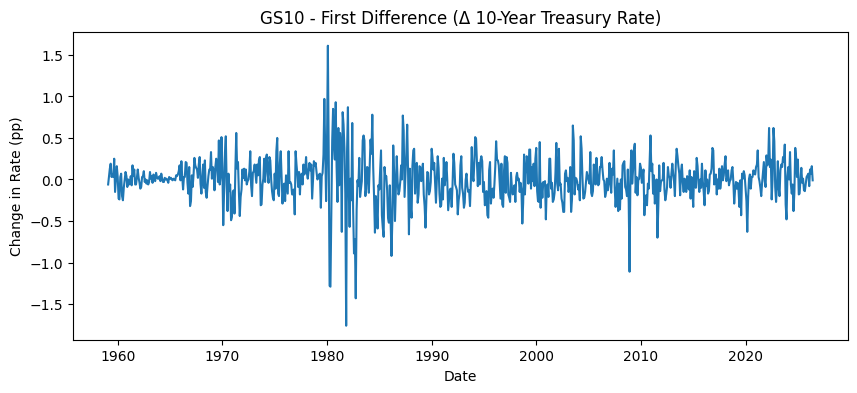

In [18]:
print("Mean:", np.mean(series))
print("Median:", np.median(series))
print("Std:", np.std(series))
print("Min:", np.min(series))
print("Max:", np.max(series))

lag1_autocorr = np.corrcoef(series[:-1], series[1:])[0, 1]
print("Lag-1 autocorrelation:", lag1_autocorr)

plt.figure(figsize=(10,4))
plt.plot(dates, series)
plt.title("GS10 - First Difference (Δ 10-Year Treasury Rate)")
plt.xlabel("Date")
plt.ylabel("Change in Rate (pp)")
plt.show()

In [ ]:
def create_windows(series, p):
    """
    series: 1D numpy array
    p: number of lags (window size)
    Returns:
      X: array of shape (num_windows, p)
      y: array of shape (num_windows,)
    """
    X, y = [], []
    for t in range(p, len(series)):
        X.append(series[t-p:t])   # p values before t
        y.append(series[t])       # the value at t
    return np.array(X), np.array(y)